# **React Agents**

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnableSequence, RunnableLambda, RunnableParallel, RunnableBranch

from dotenv import load_dotenv
import os
load_dotenv()


if os.environ['GEMINI_API_KEY']:
    print('gemini key set')
else:
    print("not set")

gemini key set


In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

## **Tools**

In [ ]:
import wikipedia
from langchain.tools import tool
wikipedia.set_user_agent(
    "LangGraphTutorial/1.0 (educational project)"
)
# Tool - 1 [News Search Tool]

from langchain_community.tools import DuckDuckGoSearchResults

search_tool = DuckDuckGoSearchResults()

# search_tool.invoke("Obama")

# Tool 2

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

# Configure the underlying Wikipedia API wrapper
api_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=1000)

# Create the tool that uses the wrapper
wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

# wikipedia_tool.invoke("what is the capital of france")


# Tool 3 [custom enterprise]
@tool
def enterprise_tool(quert:str)->str:
    """
    A tool to send emails to employees
    """
    return "Email sent"



In [ ]:
ToolKit = [search_tool, wikipedia_tool, enterprise_tool]

# ToolKit

[DuckDuckGoSearchResults(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\mbasweti\\Desktop\\projects\\langchain-tutorial\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=1000)),
 StructuredTool(name='enterprise_tool', description='A tool to send emails to employees', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x00000271299D99E0>)]

## **React Agent**

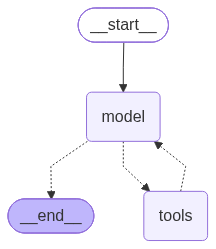

In [24]:
from langchain.agents import create_agent

agent = create_agent(model=llm, tools=ToolKit)

agent

## **React Agent Invoke with streaming**

In [26]:
example_query = "Send an email about abama to michaelbasweti@gmail.com. The email should have the life story of obama"

events = agent.stream(
    {"messages":[("user",example_query)]},
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Send an email about abama to michaelbasweti@gmail.com. The email should have the life story of obama
================================== Ai Message ==================================

[]
Tool Calls:
  wikipedia (call_48837)
 Call ID: call_48837
  Args:
    query: Barack Obama
================================= Tool Message =================================
Name: wikipedia

Page: Barack Obama
Summary: Barack Hussein Obama II (born August 4, 1961) is an American politician who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African American to serve as president. Obama represented Illinois in the United States Senate from 2005 to 2008 and served as an Illinois state senator from 1997 to 2004.
Born in Honolulu, Obama graduated from Columbia University in 1983 and later worked as a community organizer in Chicago. In 1988, Obama enrolled at 

## **Manually Binding LLM With Tools**

In [ ]:
# without binding
llm.invoke("What is the latest news about the stock market?")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


AIMessage(content=[{'type': 'text', 'text': '*Disclaimer: I am an AI, not a financial advisor. Stock market data changes rapidly throughout the day.*\n\nAs of midday **Tuesday, May 21, 2024**, here is the latest snapshot of the stock market:\n\n### 1. Market Performance\n*   **S&P 500 and Nasdaq:** Both indices are hovering near record highs. The S&P 500 is trading slightly higher, continuing the momentum from last week’s inflation data, which reignited hopes for Federal Reserve interest rate cuts later this year.\n*   **Dow Jones:** The Dow is seeing modest movement, struggling slightly to maintain the momentum that pushed it above the 40,000-point milestone for the first time last week.\n\n### 2. Key Drivers\n*   **NVIDIA Anticipation:** All eyes are on **NVIDIA (NVDA)**, which is set to report its quarterly earnings after the market closes on Wednesday. Because NVIDIA has been the primary engine driving the AI-fueled rally, investors are treating this report as a major bellwether fo

In [28]:
# with binding

llm_binded = llm.bind_tools(ToolKit)
llm_binded.invoke("What is the latest news about the stock market?")

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duckduckgo_results_json', 'arguments': '{"query": "latest stock market news"}'}, '__gemini_function_call_thought_signatures__': {'call_860673': 'EnEKbwERTTIPYNQ8SEslLl+vWvwwsd4hZBxZcMWhOby07gF7cyf4erjR/gH7ldAzQzyYe8fyWZzi+W1I17Up5+fyFsTmmCjrYuacA0AvouLDlvfp2TJeGuM+ZgbH4yEEDzREg74NQKRfZ3o6BHrnprYepQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a066a7-e3c9-7912-9570-e5f8fe966009-0', tool_calls=[{'name': 'duckduckgo_results_json', 'args': {'query': 'latest stock market news'}, 'id': 'call_860673', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 23, 'total_tokens': 241, 'input_token_details': {'cache_read': 0}})